# **<font color="red">Regression Matrics</font>**

1. __MAE :__ Mean Absolute Error
2. __MSE :__ Mean Squire Error
3. __RMSE :__ Root Mean Squire Error
4. __R2 Score :__
5. __Adjusted R2 Score :__

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/placement01.csv")
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'PKG')

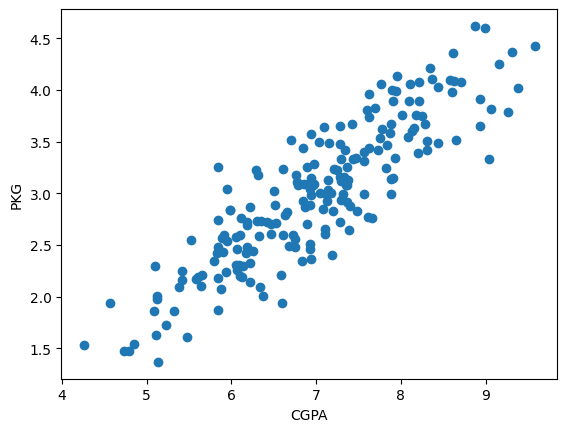

In [3]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('PKG')

In [4]:
X = df.iloc[:, 0:1]
y = df.iloc[:, -1]
X.shape, y.shape

((200, 1), (200,))

In [5]:
X.head()

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94


In [6]:
y.head()

0    3.26
1    1.98
2    3.25
3    3.67
4    3.57
Name: package, dtype: float64

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [8]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [9]:
history = lr.fit(X_train, y_train)
history

LinearRegression()

Text(0, 0.5, 'PKG')

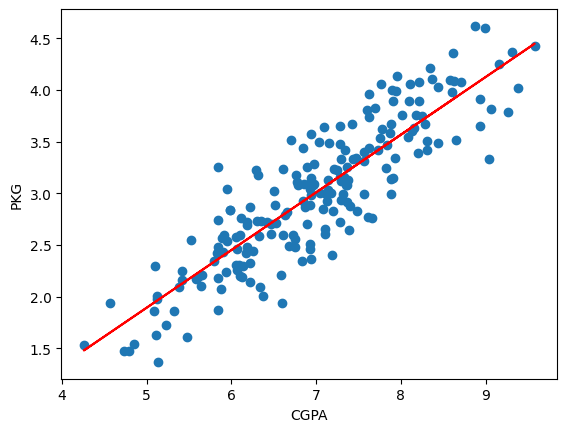

In [10]:
plt.scatter(df['cgpa'], df['package'])
plt.plot(X_train, lr.predict(X_train), color='red')
plt.xlabel('CGPA')
plt.ylabel('PKG')


## **<font color="green">Regression Matrics</font>**

In [11]:
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score
)


In [12]:
y_pred = lr.predict(X_test)
y_pred

array([3.89111601, 3.09324469, 2.38464568, 2.57434935, 1.6537286 ,
       1.77647803, 2.07219258, 2.93143862, 3.76278706, 2.93701814,
       4.09197872, 3.51170867, 2.97049525, 2.40138424, 3.18809652,
       3.46707251, 1.94386362, 3.24389172, 2.97607477, 3.41685683,
       2.55761079, 3.16577844, 2.85890486, 3.12114229, 3.68467378,
       2.8700639 , 3.49497011, 3.34432308, 3.91901361, 1.96060218,
       3.65119666, 3.2104146 , 3.74046898, 2.7863711 , 2.78079158,
       3.27178932, 3.52844723, 2.61340599, 2.65804215, 2.71383735])

In [13]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [14]:
print("MAE :", round(mean_absolute_error(y_test, y_pred), 3))
print("MSE :", round(mean_squared_error(y_test, y_pred), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, y_pred)), 3))
print("R2 Score :", round(r2_score(y_test, y_pred), 3))

MAE : 0.288
MSE : 0.121
RMSE : 0.348
R2 Score : 0.781


In [15]:
# Adjusted R2 Score
r2 = r2_score(y_test, y_pred)
n = X_test.shape[0]
k = 1
num = (1-r2)*(n - 1)
den = (n-1-k)
r2_adj = round(1 - (num/den), 3)
print("R2 Adj :", r2_adj)

R2 Adj : 0.775


#### **<font color='blue'>Test 1: Add a random column in dataset and check R2 Score and R2 Adjust</font>**

In [16]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(new_df1.shape[0])
new_df1 = new_df1[['cgpa', 'random_feature', 'package']]

new_df1.head()

,cgpa,random_feature,package
0,6.89,0.889159,3.26
1,5.12,0.551655,1.98
2,7.82,0.629424,3.25
3,7.42,0.259265,3.67
4,6.94,0.844837,3.57


Text(0, 0.5, 'package')

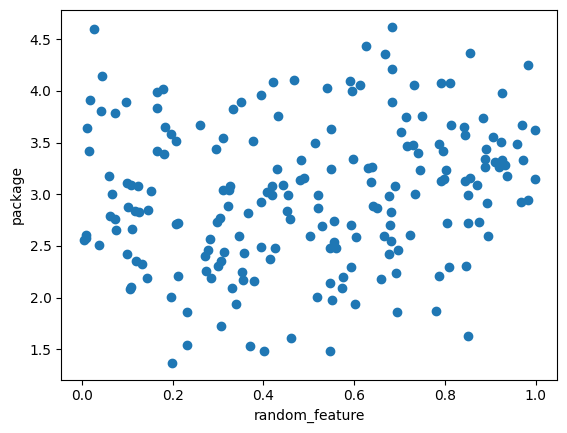

In [17]:
plt.scatter(new_df1['random_feature'], new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('package')


Text(0, 0.5, 'package')

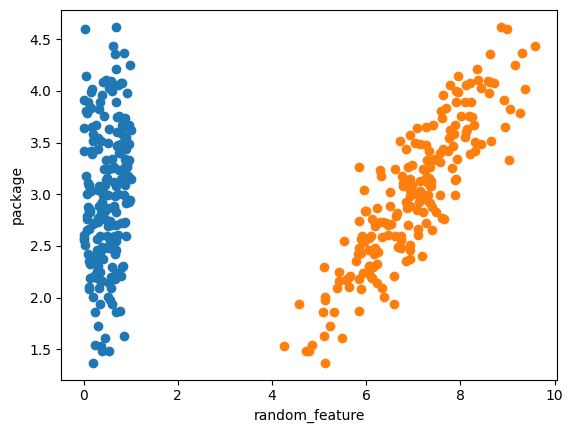

In [18]:
plt.scatter(new_df1['random_feature'], new_df1['package'])
plt.scatter(new_df1['cgpa'], new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('package')


In [19]:
X = new_df1.iloc[:, 0:2]
y = new_df1.iloc[:, -1]
X.shape, y.shape

((200, 2), (200,))

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [21]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
history = lr.fit(X_train, y_train)
history

LinearRegression()

In [22]:
y_pred = lr.predict(X_test)
y_pred

array([3.89687041, 3.15966434, 2.33338764, 2.52518856, 1.6812137 ,
       1.77363023, 2.04201626, 2.87560987, 3.78328064, 2.94090891,
       4.03646882, 3.5213825 , 2.99178761, 2.43135455, 3.18010327,
       3.48223993, 1.98218836, 3.2071035 , 2.96425547, 3.3649748 ,
       2.56894194, 3.21452518, 2.91835606, 3.06608028, 3.7213243 ,
       2.79949631, 3.44686121, 3.27500699, 3.89969482, 1.92626433,
       3.65281454, 3.26638172, 3.79595959, 2.76559106, 2.82498218,
       3.32658032, 3.53845854, 2.66140733, 2.66419195, 2.74944823])

In [23]:
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score
)


In [24]:
print("R2 Score :", round(r2_score(y_test, y_pred), 3))

R2 Score : 0.786


In [25]:
# Adjusted R2 Score
r2 = r2_score(y_test, y_pred)
n = X_test.shape[0]
k = 1
num = (1-r2)*(n - 1)
den = (n-1-k)
r2_adj = round(1 - (num/den), 3)
print("R2 Adj :", r2_adj)

R2 Adj : 0.781


#### **<font color='purple'>Test 2: Add a valuable column in dataset and check R2 Score and R2 Adjust</font>**

In [26]:
new_df2 = df.copy()
l = new_df2.shape[0]

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12, 12, l)/10)
new_df2 = new_df2[['cgpa', 'iq', 'package']]
new_df2.head()

,cgpa,iq,package
0,6.89,4.06,3.26
1,5.12,1.48,1.98
2,7.82,2.85,3.25
3,7.42,3.37,3.67
4,6.94,4.67,3.57


Text(0, 0.5, 'Package')

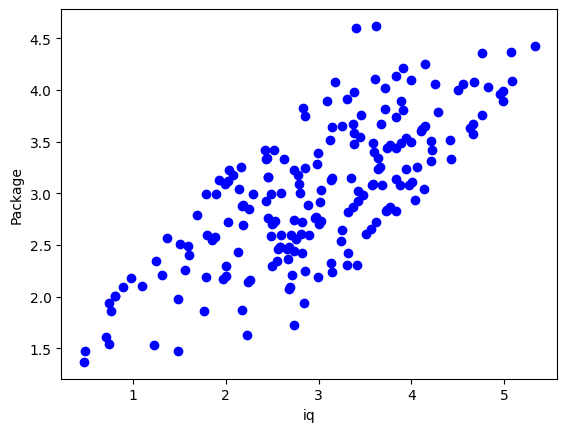

In [27]:
plt.scatter(new_df2['iq'], new_df2['package'], color='blue')
plt.xlabel('iq')
plt.ylabel('Package')

Text(0, 0.5, 'Package')

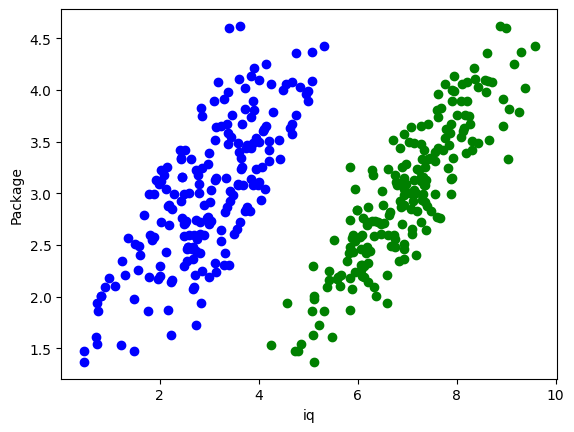

In [28]:
plt.scatter(new_df2['iq'], new_df2['package'], color='blue')
plt.scatter(new_df2['cgpa'], new_df2['package'], color='green')
plt.xlabel('iq')
plt.ylabel('Package')

In [29]:
X = new_df2.iloc[:, 0:2]
y = new_df2.iloc[:, -1]
X.shape, y.shape

((200, 2), (200,))

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [31]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [32]:
print("R2 Score :", round(r2_score(y_test, y_pred), 3))

R2 Score : 0.821


In [33]:
# Adjusted R2 Score
r2 = r2_score(y_test, y_pred)
n = X_test.shape[0]
k = 1
num = (1-r2)*(n - 1)
den = (n-1-k)
r2_adj = round(1 - (num/den), 3)
print("R2 Adj :", r2_adj)

R2 Adj : 0.816
